## CNN FASHIONMNIST DATASETS

1-Kütüphanelerin Yüklenmesi

In [29]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [30]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

2-Dataset'in Yüklenmesi ve Özellik İncelemesi

In [32]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [33]:
type(train_data)

torchvision.datasets.mnist.FashionMNIST

In [34]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [35]:
image,label = train_data[0]

In [36]:
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [37]:
label

9

In [38]:
image.shape

torch.Size([1, 28, 28])

In [39]:
class_names = train_data.classes

In [40]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

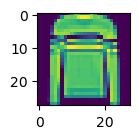

In [41]:
image,label = train_data[5]
image = image.permute(1,2,0)
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)

3-Görsellerin Tiny VGG'ye uygun hale getirilmesi # https://poloclub.github.io/cnn-explainer/

In [43]:
transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [44]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = transforms
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = transforms
)

In [45]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)

In [46]:
train_dataloader.dataset[0][0].shape

torch.Size([1, 64, 64])

In [47]:
test_dataloader.dataset[0][0].shape

torch.Size([1, 64, 64])

In [48]:
class FashionMNISTCNN(nn.Module):
    def __init__(self,input_shape,hidden_units,output_shape):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features = output_shape)
        )


    def forward(self,x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
        

In [116]:
# Modeli oluştururken girdiğim parametreleri, blok yapısını Tiny VGG'den örnek aldım.

In [49]:
model_0 = FashionMNISTCNN(1,32,len(class_names))

In [50]:
from torchinfo import summary

In [51]:
summary(model_0, input_size=[1,1,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTCNN                          [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           320
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

Kolay kullanım için train,test adımlarını fonksiyonlaştırdım

In [52]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,loss_fn:torch.nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    train_loss = 0
    train_acc = 0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)



    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [53]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,loss_fn:torch.nn.Module):
    model.eval()
    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()


            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss,test_acc

In [54]:
def train(model: torch.nn.Module, train_dataloader: torch.utils.data.DataLoader,test_dataloader: torch.utils.data.DataLoader,loss_fn:nn.CrossEntropyLoss(), optimizer: torch.optim.Optimizer, epochs: int=10):
        results = {"train_loss": [],
                  "train_acc": [],
                  "test_loss": [],
                  "test_acc": []}

        for epoch in range(epochs):
            train_loss, train_acc = train_step(model=model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer)
            test_loss, test_acc = test_step(model=model,dataloader=test_dataloader,loss_fn=loss_fn)


            print(f"Epoch {epoch}, Train_Loss: {train_loss}, Train_Acc: {train_acc}, Test_Loss: {test_loss}, Test_Acc: {test_acc}")
            results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
            results["train_acc"].append(train_acc.item()  if isinstance(train_acc, torch.Tensor) else train_acc)
            results["test_loss"].append(test_loss.item()  if isinstance(test_loss, torch.Tensor) else test_loss)
            results["test_acc"].append(test_acc.item()  if isinstance(test_acc, torch.Tensor) else test_acc)

        return results

Model Eğitim Süreci

In [55]:
EPOCHS = 10
model_0 = FashionMNISTCNN(1,32,len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),lr=0.01)

model_0_results = train(model_0,train_dataloader,test_dataloader,loss_fn,optimizer,EPOCHS)

Epoch 0, Train_Loss: 0.4632467363059521, Train_Acc: 0.83575, Test_Loss: 0.3945645357425601, Test_Acc: 0.8598242811501597
Epoch 1, Train_Loss: 0.34706609513362247, Train_Acc: 0.8758333333333334, Test_Loss: 0.35560135593334324, Test_Acc: 0.869508785942492
Epoch 2, Train_Loss: 0.32753407254815103, Train_Acc: 0.88265, Test_Loss: 0.34270778718514566, Test_Acc: 0.8748003194888179
Epoch 3, Train_Loss: 0.3150041270385186, Train_Acc: 0.8870166666666667, Test_Loss: 0.33158823563315615, Test_Acc: 0.884185303514377
Epoch 4, Train_Loss: 0.30558197177747887, Train_Acc: 0.8903666666666666, Test_Loss: 0.3506463250508324, Test_Acc: 0.8781948881789138
Epoch 5, Train_Loss: 0.3067961219837268, Train_Acc: 0.8888166666666667, Test_Loss: 0.33043017925117346, Test_Acc: 0.8833865814696485
Epoch 6, Train_Loss: 0.30206690081357956, Train_Acc: 0.8916166666666666, Test_Loss: 0.33658818891063663, Test_Acc: 0.8810902555910544
Epoch 7, Train_Loss: 0.29795372071464854, Train_Acc: 0.8930333333333333, Test_Loss: 0.34656

In [76]:
import matplotlib.pyplot as plt

Loss ve Accuracy için Grafiklerin Çizimi

In [77]:
def plot_loss_curves(results) :
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))
    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.plot(epochs,train_loss,label="train_loss")
    plt.plot(epochs,test_loss,label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs,train_accuracy,label="train_accuracy")
    plt.plot(epochs,test_accuracy,label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()
    

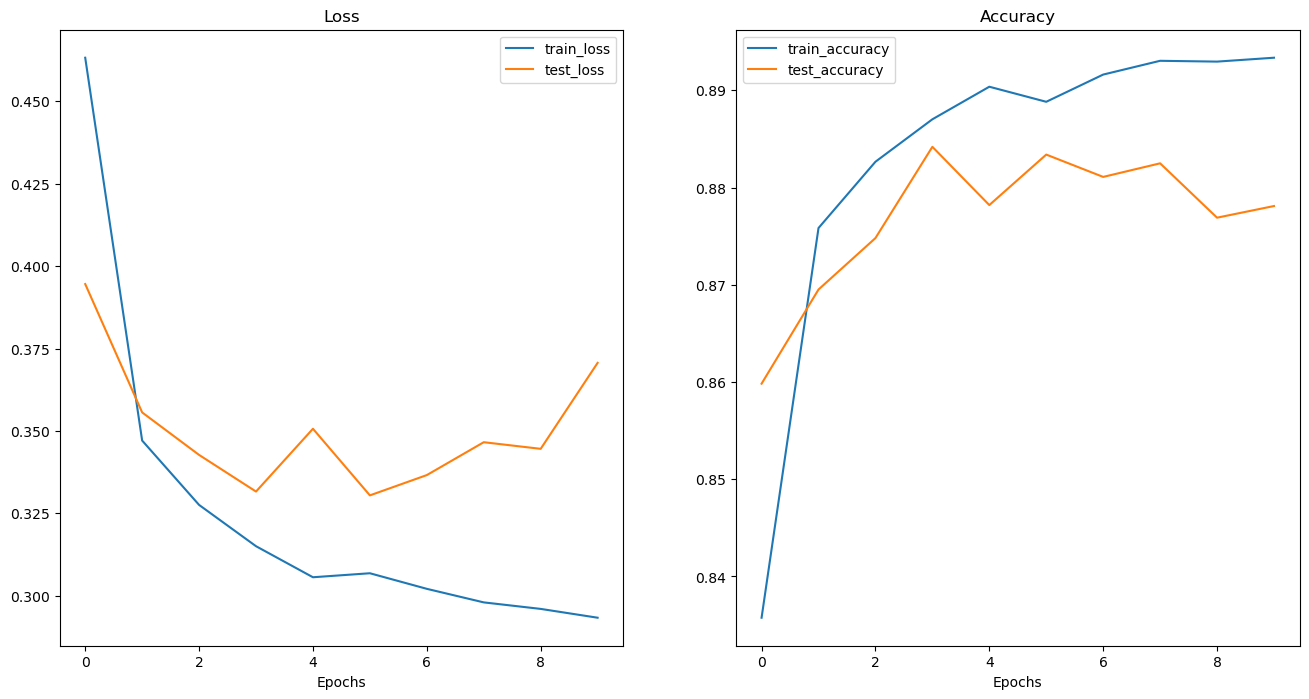

In [78]:
plot_loss_curves(model_0_results)

Rastgele seçilen görsellerin oluşturduğumuz model üzerinde testi için fonksiyonlar

In [79]:
def make_predictions(model: torch.nn.Module, data: list):
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            sample = sample.unsqueeze(0)

            pred_logit = model(sample)    

            prob = torch.softmax(pred_logit, dim=1)  

            pred_probs.append(prob.squeeze(0))      

    return torch.stack(pred_probs)

In [80]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            img_input = img.unsqueeze(0).to(device)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            img_show = img.permute(1, 2, 0)

            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

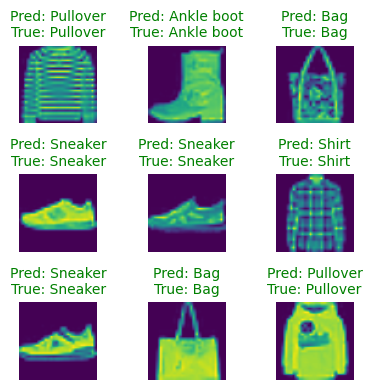

In [81]:
show_random_predictions(model_0,test_data,class_names)

İnternet üzerinden indirdiğim görselin test aşaması

In [83]:
from pathlib import Path
data_path = Path("data/")

In [107]:
online_img_path = data_path/"tisort.jpg"

In [108]:
single_image = Image.open(str(online_img_path)).convert("RGB")

In [109]:
from PIL import Image
from torchvision import transforms

single_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),      
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor()                  
])

In [110]:
single_image = single_image_transform(single_image)

In [111]:
img_input = single_image.unsqueeze(0).to(device)

Text(0.5, 1.0, 'torch.Size([1, 64, 64])')

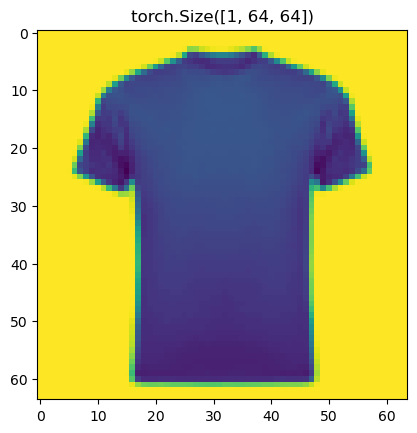

In [118]:
plt.imshow(single_image.permute(1,2,0)) # Shape'i cnn için uygun hale getirdim.
plt.title(single_image.shape)

In [113]:
img_input = single_image.unsqueeze(0).to(device)

In [114]:
model_0.eval()
with torch.inference_mode():
    logits = model_0(img_input)
    probs = torch.softmax(logits,dim=1)
    pred_id = probs.argmax(dim=1).item()

print("Predicted Class :",class_names[pred_id])

Predicted Class : Shirt


## ÖZET

TorchVision kütüphanesinden import ettiğim FashionMNIST veri seti ile CNN modelimi oluşturdum.

Transform işlemini, parametreleri Tiny VGG'den uyarlayarak belirledim.

Fazla transform işlemi ve epoch uyguladım %88'e yakın başarı yakaladım.

Dışarıdan aldığım JPG görsel ile testimi gerçekleştirdim.